# Instructions 

- Make sure you’re logged into Kaggle.
- Load the **Video Game Sales dataset** (CSV file is provided in the Kaggle input section).  
- Carefully read through each step and run the cells in order.  
- Do **not** skip steps — each builds on the previous one.  
- Add your own observations wherever possible, especially when exploring graphs.  
- Remember: This is practice for real-world data preprocessing + EDA, so try to think *why* each step is done, not just *how*.  
- At the end, feel free to explore further — add more plots, groupbys, or questions you want to answer!  



Welcome to your next checkpoint on the Synapse road!
Today we’re diving into the Video Game Sales dataset to practice real-world data preprocessing + EDA. Think of this like prepping ingredients before cooking — we’ll clean, slice, and plate the data so insights pop 🍽️

We’ll be using pandas, numpy, matplotlib, and seaborn for this task.
Run the following cell to import them

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pandas — handles tabular data (the actual dataset), 

numpy — numerical operations, 

matplotlib — basic plotting, 

seaborn — nicer statistical plots

Alright, now that we’ve got our tools ready, let’s bring in the star of the show — the **Video Game Sales dataset** 🎮  

Your task:  
- Load the dataset into a pandas DataFrame.  
- Take a quick peek at the first few rows using.  
- Check the shape of the dataset to see how big this universe is.  

Think of this step as unboxing a new console — gotta see what’s inside first!  


In [25]:
df = pd.read_csv("/kaggle/input/videogamesales/vgsales.csv")

This reads the CSV file from Kaggle's dataset folder and stores it in a variable called df (short for "DataFrame", the standard pandas term for a table of data). Nothing gets displayed yet, it just loads the data into memory.

In [26]:
print(df.head())

   Rank                      Name Platform    Year         Genre Publisher  \
0     1                Wii Sports      Wii  2006.0        Sports  Nintendo   
1     2         Super Mario Bros.      NES  1985.0      Platform  Nintendo   
2     3            Mario Kart Wii      Wii  2008.0        Racing  Nintendo   
3     4         Wii Sports Resort      Wii  2009.0        Sports  Nintendo   
4     5  Pokemon Red/Pokemon Blue       GB  1996.0  Role-Playing  Nintendo   

   NA_Sales  EU_Sales  JP_Sales  Other_Sales  Global_Sales  
0     41.49     29.02      3.77         8.46         82.74  
1     29.08      3.58      6.81         0.77         40.24  
2     15.85     12.88      3.79         3.31         35.82  
3     15.75     11.01      3.28         2.96         33.00  
4     11.27      8.89     10.22         1.00         31.37  


.head() shows you the first 5 rows of the dataset by default. 

In [27]:
print(df.shape)
print(df.columns)

(16598, 11)
Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='object')


.shape gives (16598, 11) , which tells us that it contains 16,598 rows, 11 columns

.columns tells about the lists the exact column names (Rank, Name, Platform, Year, Genre, Publisher, NA_Sales, EU_Sales, JP_Sales, Other_Sales, Global_Sales)

### 🕹️ Level 1: Meet the Characters  

Now that we’ve unboxed our dataset, let’s get to know the **cast of characters**:  
- What kinds of columns do we have? (numeric, object, etc.)  
- How many missing values are there?  

Your task:  
- To get a quick overview of column types + null values.  
- To double-check the data types.  

This step is like reading the **character bios** before starting a game   


In [28]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB
None


Shows each column's data type and how many non-null (non-missing) values it has. You found:

This output tells you what kind of data is inside your table (DataFrame) and if any information is missing.

Year: float64, 271 missing values

Publisher: object (text), 58 missing values

Everything else: complete, no missing values

In [29]:
print(df.isnull().sum())

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64


Confirms the same missing-value counts numerically, per column.

### 🎯 Level 2: Quick Stats Check (Describe the Data)  

Every good gamer checks the **stats screen** before playing  
Now, let’s do the same for our dataset:  

Your task:  
- To get summary statistics for numerical columns.  
- Notice things like average sales, max values, and distribution hints.  

This is like peeking at the **scoreboard** — who’s leading, what’s the high score?   


In [30]:
print(df.describe())

               Rank          Year      NA_Sales      EU_Sales      JP_Sales  \
count  16598.000000  16327.000000  16598.000000  16598.000000  16598.000000   
mean    8300.605254   2006.406443      0.264667      0.146652      0.077782   
std     4791.853933      5.828981      0.816683      0.505351      0.309291   
min        1.000000   1980.000000      0.000000      0.000000      0.000000   
25%     4151.250000   2003.000000      0.000000      0.000000      0.000000   
50%     8300.500000   2007.000000      0.080000      0.020000      0.000000   
75%    12449.750000   2010.000000      0.240000      0.110000      0.040000   
max    16600.000000   2020.000000     41.490000     29.020000     10.220000   

        Other_Sales  Global_Sales  
count  16598.000000  16598.000000  
mean       0.048063      0.537441  
std        0.188588      1.555028  
min        0.000000      0.010000  
25%        0.000000      0.060000  
50%        0.010000      0.170000  
75%        0.040000      0.470000  


This calculates summary statistics (count, mean, std, min, 25%/50%/75% percentiles, max) for every numeric column.

## 🧹 Level 3: Clean the Map (Missing Values)

Time to sweep the floor before we play.

**Your tasks:**
- Check how many missing values are in each column.
- For this dataset, handle missing values in **`Year`** and **`Publisher`** by removing those rows.
- Re-check to confirm there are **no missing values left**.

> Tip: Do a quick sanity check after cleaning (row count should drop a bit).


In [31]:
print("Missing values before cleaning : ")
print(df.isnull().sum())
print("Dropping rows year and publisher")
df=df.dropna(subset=["Year","Publisher"])

Missing values before cleaning : 
Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64
Dropping rows year and publisher


Confirms the same missing-value counts numerically, per column.

.dropna(subset=[...]) removes any row where either Year or Publisher is missing. This is the simplest way to clean missing data — just delete incomplete rows rather than guessing/filling values.

In [32]:
print("Missing values after cleaning : ")
print(df.isnull().sum())
print(df.info())

Missing values after cleaning : 
Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  float64
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB
None


This re-checks — you should now see 0 missing values everywhere, and your row count should have dropped from 16,598 to something a bit lower (since you removed the ~271+58 rows, though some might overlap if a row was missing both).


Dropping means completely deleting rows from your dataset, 

subset=["Year", "Publisher"]: Python checks only these two columns

.dropna(): It deletes the entire row if either cell is blank.


Why drop instead of fill? For Year, you can't really guess a game's release year accurately, so dropping is safer than making up a number that could mislead the analysis. Same logic for Publisher — inventing a fake publisher name would be misleading.

## 🔢 Level 4: Patch the `Year` Column (Data Types)

`Year` often shows up as a float (e.g., `2008.0`) because of missing values earlier.

**Your tasks:**
- Convert **`Year`** to **integer**.
- Re-run a quick `info` to confirm the dtype change.

> If conversion fails, revisit Level 3 — some NaNs may still be lurking.


In [33]:
df['Year'] = df['Year'].astype(int)
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  int64  
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.5+ MB
None


The Problem: Previously, your years looked like decimals (e.g., 2006.0). There is no such thing as a "point zero" year.The Fix: df['Year'].astype(int) converts those decimals into clean whole numbers (e.g., 2006).The Result: If you look at row 3 (Year), the Dtype has successfully changed from float64 (decimal) to int64 (whole number).

Clean Data: Notice that every single column now says exactly 16291 non-null. This confirms you have zero missing values left.Row Count: Your dataset dropped from 16,598 rows down to 16,291 rows because you successfully deleted the rows with missing information.


## 🎮 Level 5: Spotting the Legends  
Now that we’ve explored platforms and genres, let’s look at the **all-time best sellers**.  
Your task:  

List the **Top 5 best-selling video games**.  
We’ll display their **Name, Platform, Genre, and Global Sales**.  

Think of this as the **Hall of Fame of Video Games** 




In [34]:
top = df.sort_values(by="Global_Sales", ascending=False).head(5)

print("Top 5 Best-Selling :")
print(top[['Name', 'Platform', 'Genre', 'Global_Sales']])

Top 5 Best-Selling :
                       Name Platform         Genre  Global_Sales
0                Wii Sports      Wii        Sports         82.74
1         Super Mario Bros.      NES      Platform         40.24
2            Mario Kart Wii      Wii        Racing         35.82
3         Wii Sports Resort      Wii        Sports         33.00
4  Pokemon Red/Pokemon Blue       GB  Role-Playing         31.37


.sort_values(by="Global_Sales", ascending=False) — sorts the entire dataset by the Global_Sales column, from highest to lowest (ascending=False means "not smallest first," i.e., biggest first)

.head(5) — after sorting, just grab the top 5 rows (since the biggest sellers are now at the top)
This result is stored in a new variable called top

This just prints those top 5 rows, but only shows 4 specific columns (Name, Platform, Genre, Global_Sales) instead of all 11 — cleaner to read, no need to see Rank/Year/Publisher/regional sales here.


## 🎮 Level 6: Which Console Ruled the Game?  
Every console/platform has a legacy — but which one released the **most number of games**?  

Count the number of games released on each platform.  
Create a **bar chart** to visualize it.  
Finally, answer: **Which platform has the highest number of releases?** 

  


Games released by each : 
Platform
DS      2131
PS2     2127
PS3     1304
Wii     1290
X360    1234
PSP     1197
PS      1189
PC       938
XB       803
GBA      786
GC       542
3DS      499
PSV      410
PS4      336
N64      316
SNES     239
XOne     213
SAT      173
WiiU     143
2600     116
NES       98
GB        97
DC        52
GEN       27
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64
Bar Chart : 


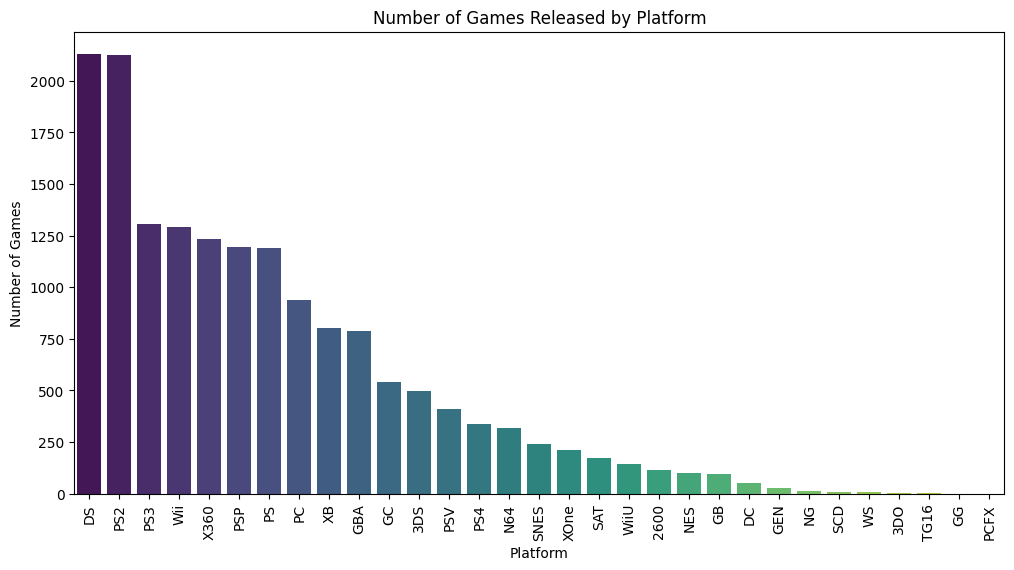

In [35]:
games_released = df['Platform'].value_counts()
print("Games released by each : ")
print(games_released)
print("Bar Chart : ")
plt.figure(figsize=(12,6))
sns.barplot(x=games_released.index, y=games_released.values, palette="viridis")
plt.xticks(rotation=90)
plt.title("Number of Games Released by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Games")
plt.show()


.value_counts() is a very common pandas trick — it looks at a column and counts how many times each unique value appears.

print(games_released)

Just prints that count table.

plt.figure(figsize=(12,6))

Creates a blank canvas for a chart, sized 12 inches wide by 6 inches tall (bigger = easier to read platform names on the x-axis).

sns.barplot(x=games_released.index, y=games_released.values, palette="viridis")

x=games_released.index — the platform names (Wii, PS2, NES, etc.) go on the horizontal axis
y=games_released.values — the actual counts (how many games) go on the vertical axis
palette="viridis" — just a color scheme (a green-to-purple gradient) to make bars look nice, purely visual

plt.xticks(rotation=90)

Rotates the platform name labels on the x-axis by 90 degrees (turns them vertical) — this is done because there are probably 20-30 different platforms, and horizontal text would all overlap and become unreadable.

plt.title("Number of Games Released by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Games")
plt.show()

Just adds a title and axis labels so the chart is self-explanatory, then .show() actually displays it.

In [36]:
print("Maximum Games : ")
print(games_released.idxmax())

Maximum Games : 
DS


print(games_released.idxmax())
.idxmax() — finds the index (label) of the highest value. Since games_released is a count of games per platform, this tells you which single platform has the most games released — answering the question asked at the top ("Which platform has the highest number of releases?").


## 🏢 Level 7: The Big Bosses (Top Publishers)  
Some publishers dominate the industry like final bosses 

Your task:  
- Find the **Top 5 publishers** with the highest **total Global Sales**.  
- Show their contribution using a **pie chart** 

This will help us see who really controlled the gaming world  


In [37]:
publisher_sales = df.groupby("Publisher")["Global_Sales"].sum().sort_values(ascending=False).head(5)

print("Top 5 : ")
print(publisher_sales)

Top 5 : 
Publisher
Nintendo                       1784.43
Electronic Arts                1093.39
Activision                      721.41
Sony Computer Entertainment     607.28
Ubisoft                         473.54
Name: Global_Sales, dtype: float64


df.groupby("Publisher") — groups all rows by publisher name (so all Nintendo games are bunched together, all EA games bunched together, etc.)

["Global_Sales"] — from each group, we only care about the Global_Sales column

.sum() — adds up all the sales within each publisher's group (so you get one total number per publisher)

.sort_values(ascending=False) — sorts those totals from highest to lowest

.head(5) — keeps just the top 5 publishers

In plain words: "Group every game by who published it, add up all their sales, then show me the 5 publishers with the biggest total."

In [ ]:
plt.figure(figsize=(8,8))
publisher_sales.plot(kind="pie", autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2"))
plt.title("Top 5 Publisher Sales ")
plt.ylabel("")  # remove y-label
plt.show()

plt.figure(figsize=(8,8))

publisher_sales.plot(kind="pie", autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2"))

kind="pie" — makes a pie chart instead of a bar chart

autopct='%1.1f%%' — shows the percentage on each pie slice, formatted with 1 decimal place (e.g., "23.4%")

startangle=140 — just rotates where the first slice starts, purely cosmetic

colors=sns.color_palette("Set2") — another preset color scheme

plt.title("Top 5 Publisher Sales ")

plt.ylabel("")  # remove y-label

plt.show()

Adds a title, removes the default y-axis label (pie charts don't need one, it looks odd otherwise), and displays it.


## 🌍 Level 8: Genre Champions in Europe  
Different genres have their own kings in different regions.  
Let’s focus on **Europe (EU Sales)** for now.  

Your task:  
- For **each Genre**, find the **Publisher** that has the highest **total EU Sales**.  
- Print the results as a list (Genre → Top Publisher).  

Think of this as awarding the **regional championship belts**  



In [ ]:
genre_publisher_sales = df.groupby(["Genre", "Publisher"])["EU_Sales"].sum()
genre_champions = genre_publisher_sales.groupby("Genre").idxmax()

print("Top Publisher in EU Sales for each Genre : ")
for genre, (g, pub) in genre_champions.items():
    print(f"{genre}: {pub}")


genre_publisher_sales = df.groupby(["Genre", "Publisher"])["EU_Sales"].sum()

This time we group by two columns together: Genre AND Publisher. So you get combinations like ("Action", "Nintendo"), ("Action", "EA"), ("Sports", "Nintendo"), etc. — every unique genre+publisher pair.

["EU_Sales"].sum() — for each of those pairs, add up their European sales total.

genre_champions = genre_publisher_sales.groupby("Genre").idxmax()

Now we regroup just by Genre (ignoring publisher for a moment)

.idxmax() — within each genre, find which publisher had the highest EU sales — i.e., the "champion" publisher for that genre

print("Top Publisher in EU Sales for each Genre : ")
  
for genre, (g, pub) in genre_champions.items():

    print(f"{genre}: {pub}")

This loops through the results one genre at a time

(g, pub) — since the original grouping was by two columns (Genre, Publisher), each result comes back as a pair; g is the genre (repeated, unused since we already have genre from the loop) and pub is the winning publisher's name

f"{genre}: {pub}" — an f-string, which just plugs the variables directly into the text, printing something like Action: Nintendo


## 🎯 Level 9: Nintendo’s Golden Year  
Nintendo is one of the biggest names in gaming 🎮  
But… which year did Nintendo achieve its **highest total Global Sales**?  
Your task:  
- Filter the dataset for **Publisher = Nintendo**.  
- Group sales by year.  
- Find the year with the **highest global sales**.  
This is like uncovering the **peak of Nintendo’s power**   



Nintendo's Golden Year was: 2006 with total Global Sales of 205.60999999999999 million.


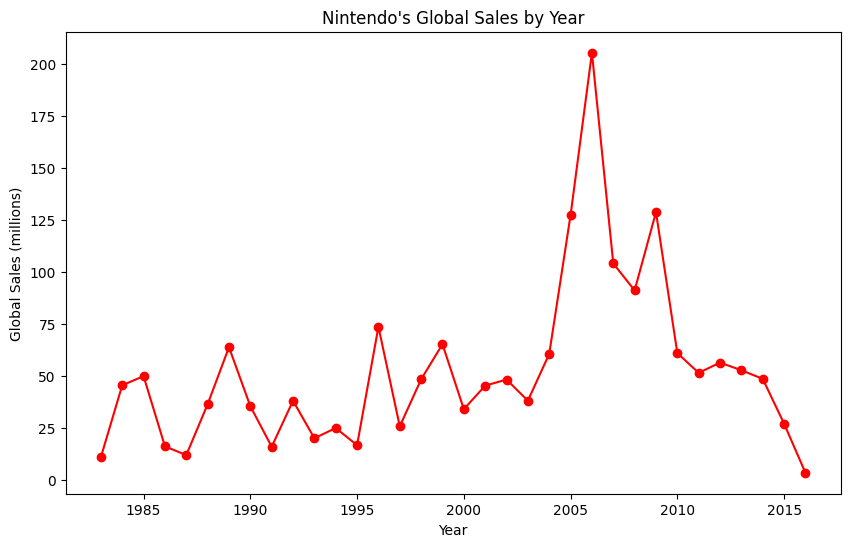

In [40]:
nintendo_games = df[df['Publisher'] == "Nintendo"]

nintendo_sales_by_year = nintendo_games.groupby("Year")["Global_Sales"].sum()

golden_year = nintendo_sales_by_year.idxmax()
golden_sales = nintendo_sales_by_year.max()

print("Nintendo's Golden Year was:", golden_year, "with total Global Sales of", golden_sales, "million.")

plt.figure(figsize=(10,6))
nintendo_sales_by_year.plot(kind="line", marker="o", color="red")
plt.title("Nintendo's Global Sales by Year")
plt.xlabel("Year")
plt.ylabel("Global Sales (millions)")
plt.show()


nintendo_games = df[df['Publisher'] == "Nintendo"]

This filters the dataset down to only rows where the Publisher column equals exactly "Nintendo" — every other publisher's games get excluded.

nintendo_sales_by_year = nintendo_games.groupby("Year")["Global_Sales"].sum()

Same pattern as before: group Nintendo's games by year, then sum up Global_Sales for each year — giving you one total sales number per year, just for Nintendo.

golden_year = nintendo_sales_by_year.idxmax()

golden_sales = nintendo_sales_by_year.max()

idxmax() — finds which year had the highest total

max() — finds what that highest total actually was (the number itself)

print("Nintendo's Golden Year was:", golden_year, "with total Global Sales of", golden_sales, "million.")

Prints a readable sentence combining both pieces of info.

plt.figure(figsize=(10,6))

nintendo_sales_by_year.plot(kind="line", marker="o", color="red")

kind="line" — makes a line chart (good for showing trends over time, like years)

marker="o" — puts a small circle dot at each actual data point on the line

color="red" — self-explanatory

Standard labeling + display, same pattern as before.


## 🏟️ Final Boss Arena: The Data Playground  

You’ve fought through all the levels ⚔️, now it’s time to explore on your own 🎉  

Your final mission:  
- Choose **any 2–3 plots** (your choice!) that show **interesting patterns** in the data.   

💡 This is your **creative zone** → Think of it as building your own “story” from the dataset.  

When you’re done, share your best plot with the team — let’s see who finds the coolest insight!  



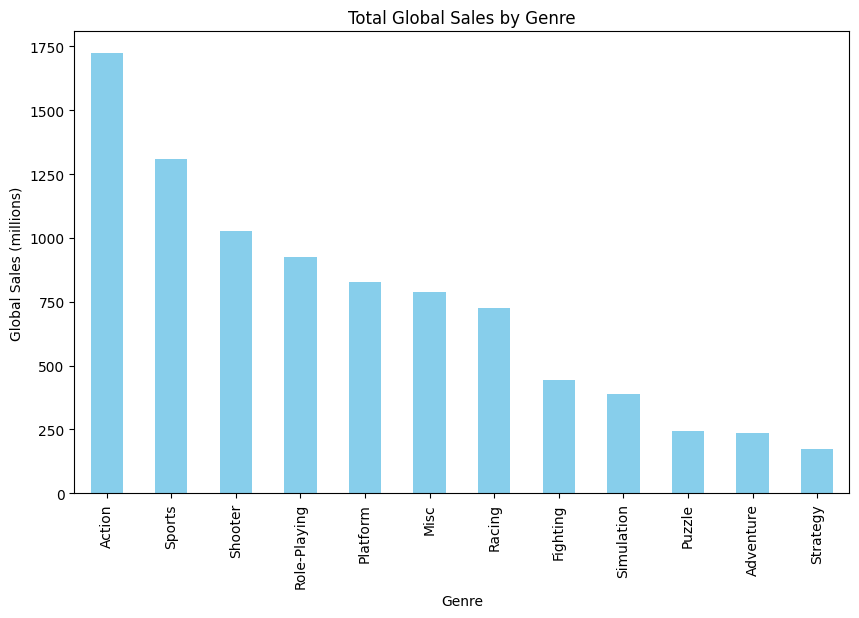

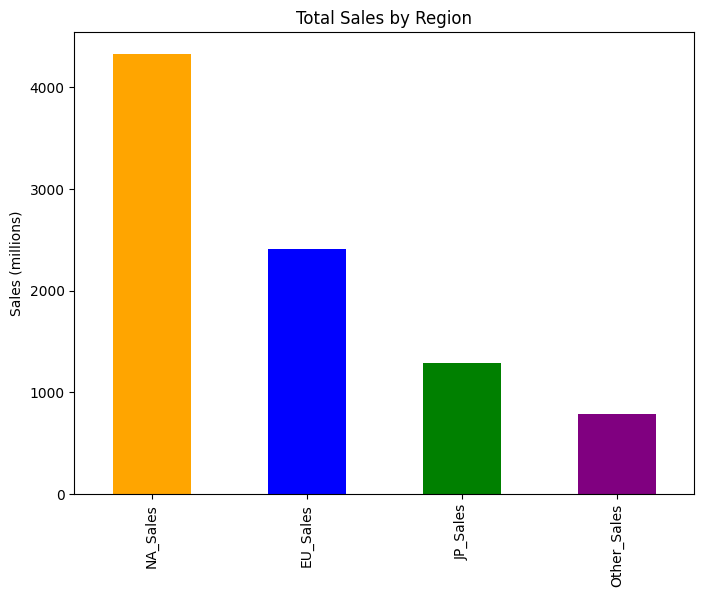

In [41]:
plt.figure(figsize=(10,6))
df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False).plot(kind="bar", color="skyblue")
plt.title("Total Global Sales by Genre")
plt.xlabel("Genre")
plt.ylabel("Global Sales (millions)")
plt.show()
regional_sales = df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum()

plt.figure(figsize=(8,6))
regional_sales.plot(kind="bar", color=["orange","blue","green","purple"])
plt.title("Total Sales by Region")
plt.ylabel("Sales (millions)")
plt.show()


plt.figure(figsize=(10,6))

df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False).plot(kind="bar", 
color="skyblue")

plt.title("Total Global Sales by Genre")

plt.xlabel("Genre")

plt.ylabel("Global Sales (millions)")

plt.show()

Same grouping pattern as before: group by Genre, sum up Global_Sales, sort biggest-first, then plot it as a bar chart. This shows which genre category (Action, Sports, RPG, etc.) has sold the most copies overall, across every publisher combined.

regional_sales = df[["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]].sum()

This selects just the four regional sales columns and adds up each one across every single game in the dataset — giving you one grand total per region (total North America sales, total Europe sales, etc.)

plt.figure(figsize=(8,6))

regional_sales.plot(kind="bar", color=["orange", "blue", "green", "purple"])

plt.title("Total Sales by Region")

plt.ylabel("Sales (millions)")

plt.show()

Plots those 4 regional totals as a bar chart, one color per bar, so you can visually compare which region (NA/EU/JP/Other) contributes the most to overall video game sales.